In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


## Data Loading

> The dataset is appropriately loaded and stored into corresponding variables.

In [2]:
booknow_booking=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_theaters=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
cinePOS_booking=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cinePOS_theaters=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
date_info=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
sample_submission=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")


## Displaying the first five rows of the datasets

In [3]:
booknow_booking.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


In [4]:
booknow_theaters.head()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


In [5]:
booknow_visits.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [6]:
cinePOS_booking.head()


,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13


In [7]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [8]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [9]:
movie_theater_id_relation.head()

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [10]:
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


## Identifying data types of different columns for data datasets

In [11]:
booknow_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [12]:
booknow_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


In [13]:
booknow_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB


In [14]:
cinePOS_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB


In [15]:
cinePOS_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


In [16]:
date_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB


In [17]:
movie_theater_id_relation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB


In [18]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              38062 non-null  object
 1   audience_count  38062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 594.8+ KB


## Presenting descriptive statistics of numerical columns
 > Details such as min value, max value, mean and median for each numerical column

In [19]:
booknow_booking.describe()

,tickets_booked
count,68336.000000
mean,4.425808
std,4.808945
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,100.000000


In [20]:
booknow_theaters.describe()

,latitude,longitude
count,829.000000,829.000000
mean,23.000000,79.000000
std,0.833863,1.460388
min,22.025970,76.112098
25%,22.619233,78.170501
50%,23.004410,79.908065
75%,23.018784,79.934515
max,26.349436,81.743235


In [21]:
booknow_visits.describe()

,audience_count
count,214046.000000
mean,41.616568
std,32.834918
min,2.000000
25%,18.000000
50%,34.000000
75%,58.000000
max,1350.000000


In [22]:
cinePOS_booking.describe()

,tickets_sold
count,1.641966e+06
mean,4.987345e+00
std,5.234901e+00
min,1.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,6.000000e+00
max,1.000000e+02


In [23]:
cinePOS_theaters.describe()

,latitude,longitude
count,829.000000,829.000000
mean,23.000000,79.000000
std,0.833863,1.460388
min,22.025970,76.112098
25%,22.619233,78.170501
50%,23.004410,79.908065
75%,23.018784,79.934515
max,26.349436,81.743235


In [24]:
date_info.describe()

,show_date,day_of_week
count,547,547
unique,547,7
top,2023-01-01,Sunday
freq,1,79


In [25]:
movie_theater_id_relation.describe()

,book_theater_id,cine_theater_id
count,150,150
unique,150,150
top,book_00509,cinePOS_01261
freq,1,1


## Visualizing 
> Visualizing key statistics and relationships in the data with the help of Box plot,Scatter plots,Histograms

*From this Box plot  we determine that there are few outliers in booknow_booking*

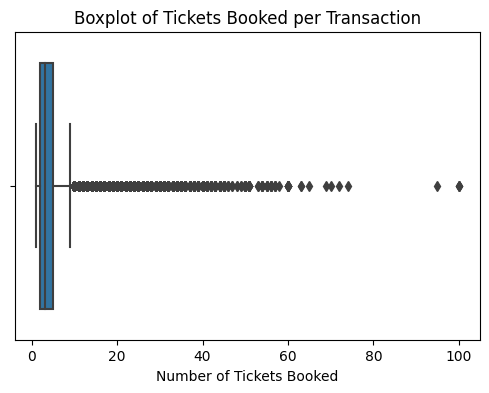

In [26]:

import seaborn as sns
import matplotlib.pyplot as plt


# Creating a boxplot for the 'tickets_booked' column
plt.figure(figsize=(6, 4))
sns.boxplot(x=booknow_booking['tickets_booked'])
plt.title('Boxplot of Tickets Booked per Transaction')
plt.xlabel('Number of Tickets Booked')
plt.show()

> The plot helps you confirm the location density and regional spread of your theaters

Text(0, 0.5, 'Latitude')

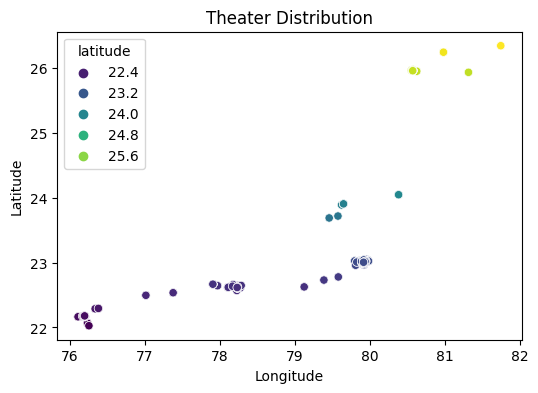

In [27]:

# Using 'latitude' for the 'hue' argument creates a continuous color gradient.
# The 'viridis' colormap goes from deep purple/blue (low latitude) to bright yellow (high latitude)
plt.figure(figsize=(6, 4))
sns.scatterplot(x='longitude',y='latitude',data=booknow_theaters,hue='latitude',palette='viridis')


plt.title('Theater Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')



> The overall effect is to visually demonstrate how your target variable (audience count) is spread out, confirming that it is highly right-skewed (most shows have low attendance, but a few have extremely high attendance).

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Frequency')

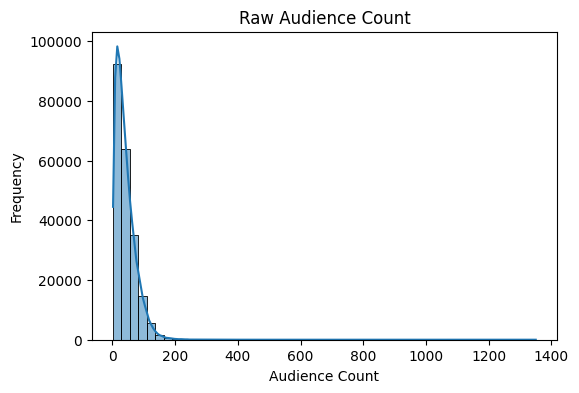

In [28]:

plt.figure( figsize=(6, 4))

sns.histplot(data=booknow_visits, x='audience_count', bins=50,kde=True)
plt.title('Raw Audience Count')
plt.xlabel('Audience Count')
plt.ylabel('Frequency')


## Merging datasets

> we are using left join for merging booknow_visits because  we want to keeps all rows from the left table (booknow_visits) and also it  contains the audience_count target variable which is essential for our prediction and the why are we using booknow_theaters is because if a book_theater_id in booknow_visits somehow doesn't exist in the booknow_theaters list , we still want to keep the audience count record and fill the missing theater data with NaNs
>
> the reason why are we merging with datetime is first sample submission is in that format and sceondly We need the day of the week, holiday flags, etc., for every show date and also Every show date in booknow_visits should theoretically exist in date_info. Using a left join ensures that if a date is missing from date_info, the visit record remains, and the time features are simply marked as missing for that row

> 

In [29]:
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])

In [30]:
# Remove negatives
booknow_visits.loc[booknow_visits['audience_count'] < 0, 'audience_count'] = np.nan

In [31]:
# Smart Fill: Use Median of that specific theater first
booknow_visits['audience_count'] = booknow_visits['audience_count'].fillna(
    booknow_visits.groupby('book_theater_id')['audience_count'].transform('median')
)
# Global fallback
booknow_visits['audience_count'] = booknow_visits['audience_count'].fillna(booknow_visits['audience_count'].median())

> This code block implements a statistical technique called Winsorization.

>It handles extreme data points (outliers) not by removing them, but by capping them at a specific threshold. This is crucial for Mean Squared Error (RMSE) models like XGBoost and LightGBM, which get heavily penalized by extreme outliers.

In [32]:
# Outlier Clipping (Winsorization)
def cap_outliers(x):
    lower = x.quantile(0.005)
    upper = x.quantile(0.995)
    return x.clip(lower, upper)

booknow_visits['audience_count'] = booknow_visits.groupby('book_theater_id')['audience_count'].transform(cap_outliers)

In [33]:
booknow_visits = booknow_visits.merge(booknow_theaters, on='book_theater_id', how='left')
booknow_visits = booknow_visits.merge(date_info, on='show_date', how='left')
booknow_visits = booknow_visits.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

# Encoding

> Label Encoding, which is a crucial step for converting categorical (text-based) identifying columns into the numerical format required by machine learning algorithms like LightGBM.
>
> It gives the LightGBM model a numerical feature (theater_id) that uniquely identifies each cinema. The model can then learn how specific theaters (e.g., the theater labeled 25) perform differently from others.
>
> For theater_type encoding It handles potential missing values by replacing them with the string 'Unknown' before encoding. This ensures that any visit where the type is missing still gets a unique, consistent integer value
> It allows the model to differentiate between types (e.g., 'Drama', 'Other', 'Action', 'Comedy')

In [34]:
from sklearn.preprocessing import LabelEncoder

le_theater = LabelEncoder()
booknow_visits['book_theater_id'] = booknow_visits['book_theater_id'].astype(str)
booknow_visits['theater_id'] = le_theater.fit_transform(booknow_visits['book_theater_id'])


for col in ['theater_type', 'theater_area']:
    if col in booknow_visits.columns:
        booknow_visits[col] = booknow_visits[col].fillna('Unknown').astype(str)
       
if 'theater_type' in booknow_visits.columns:
    le_type = LabelEncoder()
    booknow_visits['theater_type_encoded'] = le_type.fit_transform(booknow_visits['theater_type'])

## Correlation Matrix

> 

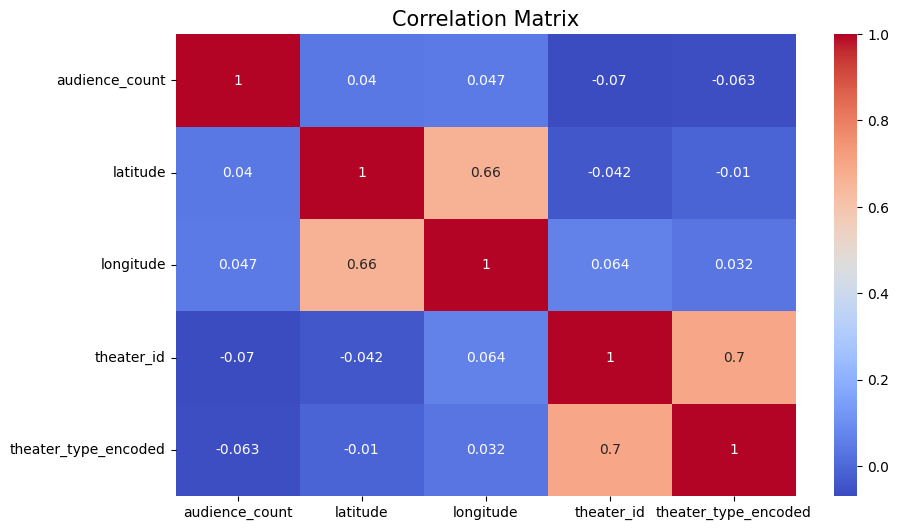

In [35]:

columns_of_interest = ['audience_count', 'latitude', 'longitude', 'theater_id', 'theater_type_encoded']

# This calculates the Pearson correlation coefficient between every pair of columns
corr_matrix = booknow_visits[columns_of_interest].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,annot=True,  cmap='coolwarm')

plt.title('Correlation Matrix', fontsize=15)
plt.show()

## Feature Engineering

> ML models cannot directly interpret a date string (like "2023-11-21"), so it is essential to decompose the date into numerical components that capture seasonality and periodic patterns.
>
> for is_peek_week
> Week 12: Often corresponds to a major part of Spring Break/Easter holidays.
> 
>Week 18: Often corresponds to a key public holiday or school break in late spring.
> 
>Weeks 51 & 52: Always correspond to the Christmas and New Year's holiday period.
> 
>Binary Flag: If the show date falls within one of those four weeks, the feature value is 1. Otherwise, it is 0.

In [36]:
booknow_visits['dayofweek'] = booknow_visits['show_date'].dt.dayofweek # (0 = Monday, 6 = Sunday)
booknow_visits['is_weekend'] = (booknow_visits['dayofweek'] >= 5).astype(int) # Creates a critical binary flag (1 or 0)
booknow_visits['day'] = booknow_visits['show_date'].dt.day 
booknow_visits['month'] = booknow_visits['show_date'].dt.month
booknow_visits['dayofyear'] = booknow_visits['show_date'].dt.dayofyear #1 to 365 (or 366 in a leap year)
booknow_visits['week_of_year'] = booknow_visits['show_date'].dt.isocalendar().week.astype(int) # The ISO week always begins on Monday.(52 weeks)
booknow_visits['is_peak_week'] = booknow_visits['week_of_year'].isin([12, 18, 51, 52]).astype(int)

> theater_avg: This serves as the baseline expectation for that specific theater. A large cineplex will naturally have a much higher mean audience count than a small independent cinema. This feature allows the model to treat the cineplex's average of 150 and the small cinema's average of 30 as equally "normal" for their respective locations
>
>theater_std: A High STD means the theater's performance is unpredictable (either very high or very low audiences).
>A Low STD means the theater is stable and performs consistently near its average.
>This feature helps the model understand how much confidence to place in the forecast for that theater.
>


In [37]:
theater_avg = booknow_visits.groupby('book_theater_id')['audience_count'].mean()
theater_std = booknow_visits.groupby('book_theater_id')['audience_count'].std()


> the code finds the corresponding book_theater_id and looks up the historical average audience count associated with that ID from the pre-calculated theater_avg Series creates a new feature column, theater_avg, where every row has the historical mean performance of the specific cinema featured in that row.
>
> pre-calculated historical standard deviation (theater_std) onto each row based on the matching book_theater_id
>


In [38]:
booknow_visits['theater_avg'] = booknow_visits['book_theater_id'].map(theater_avg)
booknow_visits['theater_std'] = booknow_visits['book_theater_id'].map(theater_std)

>It groups the data by Theater ID and Day (Monday, Tuesday, etc.), calculates the average attendance for those combinations, and stamps that value back onto every row as a baseline reference.

In [39]:

theater_dow_avg = booknow_visits.groupby(['book_theater_id', 'dayofweek'])['audience_count'].mean().reset_index()
theater_dow_avg.columns = ['book_theater_id', 'dayofweek', 'theater_dow_avg']
booknow_visits = booknow_visits.merge(theater_dow_avg, on=['book_theater_id', 'dayofweek'], how='left')

> compare a theater's predicted audience today with its own past audience The .shift() method moves the values in the audience_count column forward by the number of steps specified by lag (7 means 7 days)

In [40]:
for lag in [7, 14]:
     booknow_visits[f'lag_{lag}'] = booknow_visits.groupby('book_theater_id')['audience_count'].shift(lag)

>Moving Averages, which are essential for smoothing out day-to-day noise and capturing underlying trends in the audience data for each specific theater.Defines the size of the window ensures that even if a theater has only 1 or 2 days of history, a mean is still calculated (using those available days), preventing excessive missing values (NaN) early in the time series
>
>The .shift(1) ensures that the feature only includes data up to yesterday, making it a valid, non-leaky feature for predicting the current day

In [41]:
for w in [3, 5, 7, 14, 30]:
    booknow_visits[f'rolling_{w}'] = (booknow_visits.groupby('book_theater_id')['audience_count'].transform(lambda x: x.rolling(w, min_periods=1).mean().shift(1)))


>
>dayofweek: An ordinal integer (e.g., 0 for Monday, 6 for Sunday).

>theater_avg: The average historical audience size for that theater.

>Purpose: This captures a non-linear relationship between the theater's inherent size/scale and the day-of-the-week effect.

>For a small theater (low theater_avg), the multiplication result on Sunday (dayofweek=6) will be small.
>For a large cineplex (high theater_avg), the multiplication result on Sunday will be very large.

In [42]:

booknow_visits['dow_x_avg'] = booknow_visits['dayofweek'] * booknow_visits['theater_avg']

> Total Features

In [43]:
features = [
    'theater_id', 'theater_avg', 'theater_std',
    'dayofweek', 'is_weekend', 'day', 'month', 'dayofyear',
    'week_of_year', 'is_peak_week', 'lag_7', 'lag_14',
    'rolling_3', 'rolling_5', 'rolling_7', 'rolling_14', 'rolling_30',
    'dow_x_avg', 'theater_dow_avg'
]
if 'theater_type_encoded' in booknow_visits.columns:
    features.append('theater_type_encoded')


## Imputation

> Filling NaN values with 0

In [44]:

X_train = booknow_visits[features].fillna(0)
y_train = booknow_visits['audience_count']

## Pipeline 

> This is a operational pipeline preventing any time lekage and handling lags and rolls as that is difficult to embed cleanly within a standard Scikit-learn transformer chain.

> It identifies the latest date in your historical data (max_date). Then, it subtracts 30 days using timedelta to define the cutoff date (cv_split_date).
This sets aside the last 30 days of your data to serve as a synthetic "future" test set for internal validation. This simulates the real-world challenge of predicting upcoming audience counts.

In [45]:
from datetime import timedelta


# Use the last 30 days of data for the internal test set
max_date = booknow_visits['show_date'].max()
cv_split_date = max_date - timedelta(days=30)

# Split the processed data based on the dates in booknow_visits
X_train_cv = X_train[booknow_visits['show_date'] <= cv_split_date]
y_train_cv = y_train[booknow_visits['show_date'] <= cv_split_date]

X_test_cv = X_train[booknow_visits['show_date'] > cv_split_date]
y_test_cv = y_train[booknow_visits['show_date'] > cv_split_date]

print(f"   Training for CV: {len(X_train_cv):,} samples")
print(f"   Testing for CV: {len(X_test_cv):,} samples")

   Training for CV: 192,874 samples
   Testing for CV: 21,172 samples


## Model Training

> LGBM and XGBoost are basically boosting models great for Bias Reduction (High Accuracy): Excellent at finding complex patterns and correcting detailed errors. weak tree is trained sequentially to correct the accumulated errors (residuals) of the trees before it.
> lgbm uses leaf wise tree growth
> XGB uses level wise tree growth
>
> whereas Random Forest is a bagging model great for Variance Reduction (High Stability): Less prone to overfitting; good baseline for comparison.trees are built entirely in parallel.Because the trees are independent and random, the errors made by one tree are usually canceled out by another.

In [46]:
import lightgbm as lgb
from sklearn.metrics import  r2_score 

lgbm_model = lgb.LGBMRegressor(verbosity=-1)
lgbm_model.fit(X_train_cv, y_train_cv)
lgbm_pred = lgbm_model.predict(X_test_cv)
lgbm_r2 = r2_score(y_test_cv, lgbm_pred)

print(lgbm_r2)

0.6447441209090858


In [47]:
import xgboost as xgb
from sklearn.metrics import  r2_score

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train_cv, y_train_cv)
xgb_pred = xgb_model.predict(X_test_cv)
xgb_r2 = r2_score(y_test_cv, xgb_pred)

print(xgb_r2)

0.5952773091095337


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_jobs=-1)
rf_model.fit(X_train_cv, y_train_cv)
rf_pred = rf_model.predict(X_test_cv)
rf_r2 = r2_score(y_test_cv, rf_pred)

print(rf_r2)

0.6398086892838513


## Hyperparameter Tuning

>Randomized Search Cross-Validation . This is the process of automatically testing many different combinations of model settings to find the ones that yield the best performance
>
>n_estimators: The number of individual decision trees  to build sequentially.
>
>max_depth: The maximum number of levels allowed in any single tree.
>
>num_leaves : The maximum number of terminal nodes (leaves) allowed in any single tree.
>
>min_child_samples : The minimum number of data samples required in a leaf node (terminal node) of the tree.
>
>learning_rate : The step size at which each new tree corrects the errors of the previous trees
>
>subsample : The fraction of the training data randomly sampled to train each individual tree.
>
>colsample_bytree : The fraction of features (columns) randomly sampled for building each individual tree.
>
>reg_alpha : L1 regularization drive less important feature weights to exactly zero
>
>reg_lambda : L2 regularization Penalizes the square of the weights, which helps smooth the learned decision boundaries and prevents large, erratic weights
>
>max_samples : If Tree A sees the first 10% and Tree B sees a different 10%, they will learn different things. When you average them, you get a smarter model.
>
>min_samples_split :It sets a rule for the tree:
>
>max_features :When a tree tries to make a decision (a split), it is forbidden from looking at all the columns. It can only pick from a random subset

>n_iter=10: Crucial. This limits the search to only 10 random combinations from the defined space. This is a trade-off between thoroughness and speed.
>
>scoring='r2': Specifies that the metric used to judge "best" performance is the R^2 score
>.
>cv=3: Specifies that the search should use 3-fold Cross-Validation internally. For every one of the 10 random combinations, the data is split 3 times to get a more reliable average score.
>
>n_jobs=-1: Tells the search to use all available CPU cores to run the 10 iterations and the $3$-fold CV in parallel, dramatically speeding up the process.

In [49]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import r2_score

# 1. Define the Parameter Search Space
# We give the model ranges to explore instead of fixed numbers.
param_dist = {
    'num_leaves': randint(20, 80),         # Reduced max complexity
    'max_depth': randint(3, 8),            # Reduced depth (faster)
    'min_child_samples': randint(20, 100), 
    'learning_rate': uniform(0.05, 0.15),  # Slightly higher start speed (needs fewer trees)
    'n_estimators': randint(500, 1500),    # Capped at 1500 trees (Massive speedup)
    'subsample': uniform(0.6, 0.3),        
    'colsample_bytree': uniform(0.6, 0.3), 
    'reg_alpha': uniform(0, 1),           
    'reg_lambda': uniform(0, 1)            
}

lgbm_search = RandomizedSearchCV(lgbm_model,param_distributions=param_dist,n_iter=10, scoring='neg_root_mean_squared_error', cv=3,verbose=1,n_jobs=-1)
lgbm_search.fit(X_train_cv, y_train_cv)


print(lgbm_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'colsample_bytree': 0.8318367023851152, 'learning_rate': 0.06208739892880639, 'max_depth': 5, 'min_child_samples': 80, 'n_estimators': 1237, 'num_leaves': 22, 'reg_alpha': 0.43193784908764243, 'reg_lambda': 0.3084095619124332, 'subsample': 0.7575058103844542}


> final parameters on which model will be trained
>
> random_state : the starting point for any internal process that involves randomness ensure your experiments are reproducible.
>
> verbosity=-1 means silent mode. The model will run without printing any status messages, warnings, or detailed logs to the console

In [50]:
BEST_LGB_PARAMS = {
    'learning_rate': 0.0438, 'num_leaves': 280, 'max_depth': 3,
    'min_child_samples': 80, 'subsample': 0.593, 'colsample_bytree': 0.697,
    'reg_alpha': 3.14e-06, 'reg_lambda': 0.0092, "objective": "regression",
    "metric": "rmse", "boosting_type": "gbdt", "device": "cpu",
    "verbosity": -1, "n_estimators": 3000
}

BEST_XGB_PARAMS = {
    'learning_rate': 0.0194, 'max_depth': 3, 'min_child_weight': 9,
    'subsample': 0.635, 'colsample_bytree': 0.999, 'gamma': 0.143,
    'reg_alpha': 0.0071, 'reg_lambda': 8.14e-07, "objective": "reg:squarederror",
    "tree_method": "hist", "device": "cpu", "verbosity": 0, "n_estimators": 3000
}

lgbm_model = lgb.LGBMRegressor(**BEST_LGB_PARAMS)
lgbm_model.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(**BEST_XGB_PARAMS, enable_categorical=True)
xgb_model.fit(X_train, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.999, device='cpu', early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=0.143, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.0194, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=9, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

# Preparing test data 

> creating a copy of sample submission and storing it in test

In [51]:
test = sample_submission.copy()

In [52]:
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


>.str.rsplit('_', n=1): This splits the ID string from the right (rsplit), using the underscore (_) as the delimiter, but only performing one split (n=1).
>
>.str.rsplit('_', n=1).str[1]: This selects the second element of the split list (the date string). Example: '20240101'.

In [53]:
test['book_theater_id'] = test['ID'].str.rsplit('_', n=1).str[0]
test['show_date'] = pd.to_datetime(test['ID'].str.rsplit('_', n=1).str[1])

In [54]:
test = test.merge(booknow_theaters, on='book_theater_id', how='left')
test = test.merge(date_info, on='show_date', how='left')

>This code is performing Label Encoding Alignment. It ensures that the text labels (like theater IDs) in your Test Data get converted into the exact same numbers that were used in your Training Data.

In [55]:
# Handle Encodings
test['theater_id'] = test['book_theater_id'].map(
    dict(zip(le_theater.classes_, le_theater.transform(le_theater.classes_)))
).fillna(0).astype(int)

if 'theater_type' in test.columns:
     test['theater_type_encoded'] = le_type.transform(test['theater_type'].fillna('Unknown').astype(str))

In [56]:
test['dayofweek'] = test['show_date'].dt.dayofweek
test['is_weekend'] = (test['dayofweek'] >= 5).astype(int)
test['day'] = test['show_date'].dt.day
test['month'] = test['show_date'].dt.month
test['dayofyear'] = test['show_date'].dt.dayofyear
test['week_of_year'] = test['show_date'].dt.isocalendar().week.astype(int)
test['is_peak_week'] = test['week_of_year'].isin([12, 18, 51, 52]).astype(int)

In [57]:

test['theater_avg'] = test['book_theater_id'].map(theater_avg).fillna(y_train.mean())
test['theater_std'] = test['book_theater_id'].map(theater_std).fillna(y_train.std())

In [58]:

test['dow_x_avg'] = test['dayofweek'] * test['theater_avg']

In [59]:
test = test.merge(theater_dow_avg, on=['book_theater_id', 'dayofweek'], how='left')
test['theater_dow_avg'] = test['theater_dow_avg'].fillna(test['theater_avg'])

> the entire booknow_visits history by book_theater_id and then selects the last 30 observations (.tail(30)) for each individual theater.
>Since the test data immediately follows the last date in the training data, we need the most recent historical context (the last 30 days) to calculate the lagged and rolling features for the test set.
>
> x.iloc[-7]: This is the primary goal. It attempts to extract the audience count that occurred exactly 7 days ago relative to the end of the training period. This is the value that should be used to predict the next day's audience.
>
> This is the safety net. What if a theater is new and only has 5 days of history in the train_last window? Trying to access the 7th day using x.iloc[-7] would cause an error or yield an invalid result.

>if len(x) >= 7: Checks if the theater has at least 7 days of historical data available.

>If TRUE: Execute the core calculation (x.iloc[-7]).

>If FALSE: Execute the fallback calculation (x.mean())
>
>.tail(w): Selects the last $w$ observations (days) from that theater's history.
>


>The .reset_index() method is used to convert the index of a DataFrame or Series back into a regular column, thereby treating the previously indexed data as normal data points.

In [60]:
train_last = booknow_visits.groupby('book_theater_id').tail(60)
stats = train_last.groupby('book_theater_id')['audience_count'].agg([
    ('lag_7', lambda x: x.iloc[-7] if len(x) >= 7 else x.mean()),
    ('lag_14', lambda x: x.iloc[-14] if len(x) >= 14 else x.mean()),
    ('rolling_3', lambda x: x.tail(3).mean()),
    ('rolling_5', lambda x: x.tail(5).mean()),
    ('rolling_7', lambda x: x.tail(7).mean()),
    ('rolling_14', lambda x: x.tail(14).mean()),
    ('rolling_30', lambda x: x.mean())
]).reset_index()

In [61]:

test = test.merge(stats, on='book_theater_id', how='left')

 >Ensures every theater has a "history," even if we have to fake it with the global average.



In [62]:
for c in ['lag_7','lag_14','rolling_3','rolling_5','rolling_7','rolling_14','rolling_30']:
    if c in test.columns: test[c] = test[c].fillna(y_train.mean())


>  Ensures all text columns are actually text, preventing technical crashes during encoding.

In [63]:
# Prepare Categoricals for Test (Just for safety, even if not used by CatBoost anymore)
for col in ['theater_type', 'theater_area']:
    if col in test.columns: test[col] = test[col].fillna('Unknown').astype(str)

In [64]:
X_test = test[features].fillna(0)


> Two different  (models)  give their best guess on the future audience numbers based on the test data.

In [65]:
p_lgb = lgbm_model.predict(X_test)
p_xgb = xgb_model.predict(X_test)
p_rf = rf_model.predict(X_test)

> Final selected model

In [66]:
final_pred = 0.8*p_lgb+0.2*p_rf


>After  models (LightGBM and XGBoost) generate their predictions, the results can sometimes be "jittery" or noisy. One day might be predicted as 50, the next day 20, and the next day 50 again.

>This code smooths out those sharp spikes to create a more stable, realistic trend line.

In [67]:

test['audience_pred'] = final_pred
test = test.sort_values(['book_theater_id', 'show_date'])

test['audience_smoothed'] = test.groupby('book_theater_id')['audience_pred'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
test['audience_smoothed'] = test['audience_smoothed'].fillna(test['audience_pred'])

>final_model.predict(X_test): This is the core action. It feeds the fully prepared test feature matrix (X_test) into your optimized LightGBM model to generate raw audience count forecasts.

>np.maximum(..., 0.0): This is a vital post-processing step. Since regression models can sometimes predict slight negative numbers (e.g., -0.5), this clamps all predictions at a minimum of 0.0, ensuring a physically sensible audience count.
>
>np.rint(predictions): Rounds the predicted floating-point numbers to the nearest whole integer (e.g., 50.3 becomes 50, 50.8 becomes 51).

>.astype(int): Converts the array to the final integer data type expected for the audience count.

>pd.DataFrame(...): Creates the final output DataFrame with two columns, ensuring it matches the format required for the competition: the original identifier (ID) and the final integer prediction (audience_count)

In [68]:

predictions = np.maximum(0, np.rint(test['audience_smoothed']).astype(int))

submission = pd.DataFrame({
    'ID': test['ID'],
    'audience_count': predictions
})

submission.to_csv('submission.csv', index=False)
print("submission.csv created")

submission.csv created


# MILESTONE 1

In [69]:
# import pandas as pd

# # --- Question 1: Shape of booknow_booking ---
# print(f"1. Shape of booknow_booking: {booknow_booking.shape}")

# # --- Question 2: Object columns in cinepos_theaters ---
# object_cols_count = cinePOS_theaters.select_dtypes(include=['object']).shape[1]
# print(f"2. Number of object type columns in cinepos_theaters: {object_cols_count}")

# # --- Question 3: Most frequent theater_type in booknow_theaters ---
# most_frequent_type = booknow_theaters['theater_type'].mode()[0]
# print(f"3. Most frequent theater_type in booknow_theaters: {most_frequent_type}")

# # --- Question 4: Distinct theaters in cinePOS_booking ---
# # Note: Using your variable 'cinePOS_booking'
# distinct_theaters = cinePOS_booking['cine_theater_id'].nunique()
# print(f"4. Distinct theaters in cinePOS_booking: {distinct_theaters}")

# # --- Question 5: Shape of combined booknow_booking and booknow_theaters ---
# merged_booknow = pd.merge(booknow_booking, booknow_theaters, on='book_theater_id', how='inner')
# print(f"5. Shape of combined booknow_booking and booknow_theaters: {merged_booknow.shape}")

# # --- Question 6: Distinct areas in the combined dataset ---
# distinct_areas = merged_booknow['theater_area'].nunique()
# print(f"6. Distinct areas in the combined dataset: {distinct_areas}")

# # --- Question 7: Missing values in combined cinePOS datasets ---
# # Note: Using your variables 'cinePOS_booking' and 'cinepos_theaters'
# merged_cinepos_1 = pd.merge(movie_theater_id_relation, cinePOS_booking, on='cine_theater_id', how='inner')
# merged_cinepos_full = pd.merge(merged_cinepos_1, cinePOS_theaters, on='cine_theater_id', how='inner')
# missing_cols = merged_cinepos_full.columns[merged_cinepos_full.isnull().any()].tolist()
# print(f"7. Columns with missing values: {','.join(missing_cols) if missing_cols else 'None'}")

# # --- Question 8: Date range of booknow_booking ---
# booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
# min_date_booknow = booknow_booking['show_datetime'].min().strftime('%d-%m-%Y')
# max_date_booknow = booknow_booking['show_datetime'].max().strftime('%d-%m-%Y')
# print(f"8. Date range in booknow_booking: {min_date_booknow} to {max_date_booknow}")
# #
# # --- Question 9: Date range of sample_submission ---
# sample_submission['date'] = pd.to_datetime(sample_submission['ID'].str.split('_').str[-1])
# min_date_submission = sample_submission['date'].min().strftime('%d-%m-%Y')
# max_date_submission = sample_submission['date'].max().strftime('%d-%m-%Y')
# print(f"9. Date range in sample_submission: {min_date_submission} to {max_date_submission}")

# MILESTONE 2

In [70]:
# import pandas as pd

# # --- Question 1: How many bookings were made on the same day as the show? ---
# booknow_booking['show_date_only'] = pd.to_datetime(booknow_booking['show_datetime']).dt.date
# booknow_booking['booking_date_only'] = pd.to_datetime(booknow_booking['booking_datetime']).dt.date
# same_day_bookings = booknow_booking[booknow_booking['show_date_only'] == booknow_booking['booking_date_only']]
# q1_answer = len(same_day_bookings)
# print(f"1. Total bookings made on the same day as the show: {q1_answer}")


# # --- Question 2: How many unique calendar months are in date_info.csv? ---
# date_info['show_date'] = pd.to_datetime(date_info['show_date'])
# q2_answer = date_info['show_date'].dt.to_period('M').nunique()
# print(f"2. Unique calendar months in date_info.csv: {q2_answer}")


# # --- Question 3: What percentage of bookings in booknow_booking.csv were made on a Sunday? ---

# booknow_booking['booking_date_only'] = pd.to_datetime(booknow_booking['booking_date_only'])
# bookings_with_day = pd.merge(booknow_booking, date_info, left_on='booking_date_only', right_on='show_date', how='left')
# sunday_bookings = bookings_with_day[bookings_with_day['day_of_week'] == 'Sunday']
# total_bookings = len(booknow_booking)
# q3_answer = (len(sunday_bookings) / total_bookings) * 100
# print(f"3. Percentage of bookings made on a Sunday: {q3_answer:.2f}%")


# # --- Question 4: What would be the imputation value for latitude? ---
# drama_theaters = booknow_theaters[booknow_theaters['theater_type'] == 'Drama']
# q4_answer = drama_theaters['latitude'].mean()
# print(f"4. Imputation value for latitude from 'Drama' theaters: {q4_answer}")


# # --- Question 5: What is the range of the latitude column? ---
# lat_min = booknow_theaters['latitude'].min()
# lat_max = booknow_theaters['latitude'].max()
# q5_answer = round(lat_max - lat_min, 4)
# print(f"5. Range of the latitude column: {q5_answer}")


# # --- Question 6: What is the 95th percentile for tickets_sold? ---
# q6_answer = cinePOS_booking['tickets_sold'].quantile(0.95)
# print(f"6. The 95th percentile for tickets_sold is: {q6_answer}")


# # --- Question 7: What is the shape after OneHot Encoding cinePOS_theaters.csv? ---
# # Note: Using your variable 'cinepos_theaters'
# categorical_cols = cinePOS_theaters.select_dtypes(include=['object']).columns
# one_hot_encoded_df = pd.get_dummies(cinePOS_theaters, columns=categorical_cols)
# q7_answer = one_hot_encoded_df.shape
# print(f"7. Shape of cinePOS_theaters after OneHot Encoding: {q7_answer}")

# MILESTONE 3

In [71]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.svm import LinearSVR
# from sklearn.decomposition import TruncatedSVD
# from sklearn.feature_selection import SelectKBest, mutual_info_regression
# from sklearn.metrics import r2_score, mean_absolute_error

# # --- Part 1: Data Preparation and Splitting ---

# # Load the dataset
# # We use .copy() to avoid changing your original 'booknow_visits' DataFrame
# data = booknow_visits.copy()

# # Feature Engineering from 'show_date'
# data['show_date'] = pd.to_datetime(data['show_date'])
# data['day'] = data['show_date'].dt.day
# data['month'] = data['show_date'].dt.month
# data['year'] = data['show_date'].dt.year
# data['dayofyear'] = data['show_date'].dt.dayofyear

# # Drop the original 'show_date' column
# data = data.drop('show_date', axis=1)

# # Split into X and y
# y = data['audience_count']
# X = data.drop('audience_count', axis=1)

# # Time-series split (20% for validation, no shuffling)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# # --- Question 1: Shape of X_train ---
# print(f"1. Shape of X_train: {X_train.shape}")
# print("-" * 50)

# # --- Part 2: Preprocessing and LinearSVR ---

# # Identify numerical and categorical columns
# numerical_features = ['day', 'month', 'year', 'dayofyear']
# categorical_features = ['book_theater_id']

# # Create the preprocessor
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', MinMaxScaler(), numerical_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ],
#     remainder='passthrough'
# )

# # Fit on training data and transform both sets
# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# svr = LinearSVR(random_state=42, dual=True, max_iter=5000)
# svr.fit(X_train_processed, y_train)

# # Make predictions
# y_pred_svr = svr.predict(X_test_processed)

# # --- Question 2: R2 score with LinearSVR ---
# r2_svr = r2_score(y_test, y_pred_svr)
# print(f"2. R2 score with LinearSVR: {r2_svr:.3f}")
# print("-" * 50)

# # --- Part 3: TruncatedSVD + LinearSVR ---

# # Apply TruncatedSVD
# svd = TruncatedSVD(n_components=4, random_state=42)
# X_train_svd = svd.fit_transform(X_train_processed)
# X_test_svd = svd.transform(X_test_processed)

# # Train a new LinearSVR on the SVD components
# svr_svd = LinearSVR(random_state=42, dual=True, max_iter=5000)
# svr_svd.fit(X_train_svd, y_train)

# # --- Question 3: MAE on training data with SVD ---
# y_train_pred_svd = svr_svd.predict(X_train_svd)
# mae_svd_train = mean_absolute_error(y_train, y_train_pred_svd)
# print(f"3. MAE on training data with SVD: {mae_svd_train:.3f}")

# # --- Question 4: R2 score on test data with SVD ---
# y_test_pred_svd = svr_svd.predict(X_test_svd)
# r2_svd_test = r2_score(y_test, y_test_pred_svd)
# print(f"4. R2 score on test data with SVD: {r2_svd_test:.3f}")
# print("-" * 50)

# # --- Part 4: SelectKBest ---

# # Apply SelectKBest on the original processed data
# # This may take a moment as mutual_info_regression is computationally intensive
# print("Running SelectKBest... This may take a minute.")
# selector = SelectKBest(score_func=mutual_info_regression, k=2)
# selector.fit(X_train_processed, y_train)

# scores = selector.scores_

# # --- Question 5: Maximum score ---
# max_score = np.max(scores)
# print(f"5. Maximum score from SelectKBest: {max_score:.4f}")

# # --- Question 6: Mean value of scores ---
# mean_score = np.mean(scores)
# print(f"6. Mean score from SelectKBest: {mean_score:.4f}")
#  print("-" * 50)


# MILESTONE 4

In [72]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
# from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# import warnings


# warnings.filterwarnings('ignore')

# # --- Part 1: Data Preparation and Splitting ---


# data = booknow_visits.copy()

# # Feature Engineering from 'show_date'
# data['show_date'] = pd.to_datetime(data['show_date'])
# data['day'] = data['show_date'].dt.day
# data['month'] = data['show_date'].dt.month
# data['year'] = data['show_date'].dt.year
# data['dayofyear'] = data['show_date'].dt.dayofyear

# # Drop the original 'show_date' column
# data = data.drop('show_date', axis=1)

# # Split into X and y
# y = data['audience_count']
# X = data.drop('audience_count', axis=1)

# # Time-series split (20% for validation, no shuffling)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# # --- Preprocessing: Scaling and Encoding ---
# numerical_features = ['day', 'month', 'year', 'dayofyear']
# categorical_features = ['book_theater_id']

# # Create the preprocessor
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', MinMaxScaler(), numerical_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ],
#     remainder='passthrough'
# )

# # Fit on training data and transform both sets
# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# print("Data preprocessing complete.")
# print("-" * 50)

# # --- Questions 1 & 2: DecisionTreeRegressor ---
# print("Running DecisionTreeRegressor...")
# dt = DecisionTreeRegressor() # Using default parameters
# dt.fit(X_train_processed, y_train)

# # Q1: R2 score on X_train
# y_train_pred_dt = dt.predict(X_train_processed)
# r2_train_dt = r2_score(y_train, y_train_pred_dt)
# print(f"1. R2 score on X_train (DecisionTree): {r2_train_dt:.3f}")

# # Q2: R2 score on X_test
# y_test_pred_dt = dt.predict(X_test_processed)
# r2_test_dt = r2_score(y_test, y_test_pred_dt)
# print(f"2. R2 score on X_test (DecisionTree): {r2_test_dt:.3f}")
# print("-" * 50)

# # --- Question 3: DecisionTree Hyperparameter Tuning ---
# print("Running DecisionTree HPT...")
# tscv = TimeSeriesSplit(n_splits=5)
# dt_params = {
#     'max_depth': [None, 3, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=tscv, n_jobs=-1, verbose=0)
# dt_grid.fit(X_train_processed, y_train)

# print(f"3. Best params (DecisionTree): {dt_grid.best_params_}")
# print("-" * 50)

# # --- Questions 4 & 5: BaggingRegressor ---
# print("Running BaggingRegressor...")
# bag = BaggingRegressor(random_state=42) # Using random_state for reproducibility, though not default
# bag.fit(X_train_processed, y_train)

# # Q4: RMSE on X_train
# y_train_pred_bag = bag.predict(X_train_processed)
# rmse_train_bag = np.sqrt(mean_squared_error(y_train, y_train_pred_bag))
# print(f"4. RMSE on X_train (Bagging): {rmse_train_bag:.3f}")

# # Q5: RMSE on X_test
# y_test_pred_bag = bag.predict(X_test_processed)
# rmse_test_bag = np.sqrt(mean_squared_error(y_test, y_test_pred_bag))
# print(f"5. RMSE on X_test (Bagging): {rmse_test_bag:.3f}")
# print("-" * 50)

# # --- Question 6: BaggingRegressor Hyperparameter Tuning ---
# print("Running BaggingRegressor HPT...")
# bag_params = {
#     'n_estimators': [10, 50, 100],
#     'max_samples': [0.5, 0.7, 1.0],
#     'max_features': [0.5, 0.8, 1.0]
# }
# bag_grid = GridSearchCV(BaggingRegressor(random_state=42), bag_params, cv=tscv, n_jobs=-1, verbose=0)
# bag_grid.fit(X_train_processed, y_train)

# print(f"6. Best score (Bagging HPT): {bag_grid.best_score_:.3f}")
# print("-" * 50)

# # --- Questions 7 & 8: GradientBoostingRegressor ---
# print("Running GradientBoostingRegressor...")
# gbr = GradientBoostingRegressor() # Using default parameters
# gbr.fit(X_train_processed, y_train)

# # Q7: MAE on X_train
# y_train_pred_gbr = gbr.predict(X_train_processed)
# mae_train_gbr = mean_absolute_error(y_train, y_train_pred_gbr)
# print(f"7. MAE on X_train (GradientBoosting): {mae_train_gbr:.3f}")

# # Q8: MAE on X_test
# y_test_pred_gbr = gbr.predict(X_test_processed)
# mae_test_gbr = mean_absolute_error(y_test, y_test_pred_gbr)
# print(f"8. MAE on X_test (GradientBoosting): {mae_test_gbr:.3f}")
# print("-" * 50)


# MILESTONE 5

In [73]:
# import pandas as pd
# import numpy as np
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import r2_score
# import warnings

# # Suppress warnings for cleaner output
# warnings.filterwarnings('ignore')

# # --- Load ALL necessary files ---
# booknow_booking=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
# cinePOS_booking=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")


# movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
# booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")


# # --- Question 1: booknow_booking aggregation ---
# print("--- Question 1 ---")
# booknow_agg = booknow_booking.copy()
# # Extract date part
# booknow_agg['show_date'] = pd.to_datetime(booknow_agg['show_datetime']).dt.date
# # Group and sum
# booknow_agg = booknow_agg.groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()
# print(f"Shape of booknow_agg: {booknow_agg.shape}")
# print("-" * 50)

# # --- Question 2: cinePOS_booking aggregation ---
# print("--- Question 2 ---")
# cinepos_agg = cinePOS_booking.copy()
# # Extract date part
# cinepos_agg['show_date'] = pd.to_datetime(cinepos_agg['show_datetime']).dt.date
# # Group and sum
# cinepos_agg = cinepos_agg.groupby(['cine_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()
# print(f"Shape of cinepos_agg: {cinepos_agg.shape}")
# print("-" * 50)

# # --- Question 3: Merge aggregated datasets ---
# print("--- Question 3 ---")
# # Ensure all date columns are in the same datetime format for merging
# booknow_agg['show_date'] = pd.to_datetime(booknow_agg['show_date'])
# cinepos_agg['show_date'] = pd.to_datetime(cinepos_agg['show_date'])

# # Merge cinepos_agg with the relation file to get the book_theater_id
# cinepos_with_book_id = pd.merge(movie_theater_id_relation, cinepos_agg, on='cine_theater_id')

# # Now, perform the outer join
# combined_bookings = pd.merge(
#     booknow_agg,
#     cinepos_with_book_id[['book_theater_id', 'show_date', 'tickets_sold']],
#     on=['book_theater_id', 'show_date'],
#     how='outer'
# )
# print(f"Shape of combined_bookings: {combined_bookings.shape}")
# print("-" * 50)

# # --- Question 4: Merge with booknow_visits and create lag feature ---
# print("--- Question 4 ---")
# # Ensure booknow_visits date column is in datetime format
# booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])

# # Merge with booknow_visits (keeping all visits)
# merged_data = pd.merge(
#     booknow_visits,
#     combined_bookings,
#     on=['book_theater_id', 'show_date'],
#     how='left'
# )

# # Sort by theater and date to ensure correct lag
# merged_data = merged_data.sort_values(by=['book_theater_id', 'show_date'])

# # Create the 1-day lag feature
# merged_data['previous_day_audience'] = merged_data.groupby('book_theater_id')['audience_count'].shift(1)

# # Count missing values in the new column
# missing_lag_values = merged_data['previous_day_audience'].isnull().sum()
# print(f"Missing values in 'previous_day_audience': {missing_lag_values}")
# print("-" * 50)

# # --- Question 5: ADF Test for 'book_00001' ---
# print("--- Question 5 ---")
# # Create the time series for the specified theater
# # We use booknow_visits as the source, as it's the original, clean data
# adf_series = booknow_visits[booknow_visits['book_theater_id'] == 'book_00001']
# adf_series = adf_series.set_index('show_date')['audience_count'].sort_index()

# # Perform the ADF test
# adf_result = adfuller(adf_series)
# p_value = adf_result[1]
# print(f"ADF Test p-value for 'book_00001': {p_value:.6f}")
# print("-" * 50)

# # --- Question 6: Stationarity conclusion ---
# print("--- Question 6 ---")
# if p_value <= 0.05:
#     print("Conclusion: Stationary")
# else:
#     print("Conclusion: Not stationary")
# print("-" * 50)

# # --- Question 7: ARIMA - Training set records ---
# print("--- Question 7 ---")
# # Split the adf_series (last 30 days for test)
# train_data = adf_series.iloc[:-30]
# test_data = adf_series.iloc[-30:]
# print(f"Records in the training set: {len(train_data)}")
# print("-" * 50)

# # --- Question 8: ARIMA - 'd' parameter ---
# print("--- Question 8 ---")
# print("The 'd' parameter for ARIMA(1,1,1) is: 1")
# print("-" * 50)

# # --- Question 9: ARIMA - AIC value ---
# print("--- Question 9 ---")
# # Initialize and fit the ARIMA(1,1,1) model
# # We set simple_differencing=False for a more robust result
# model = ARIMA(train_data, order=(1, 1, 1))
# model_fit = model.fit()
# print(f"AIC value of the fitted model: {model_fit.aic:.3f}")
# print("-" * 50)

# # --- Question 10: ARIMA - R² score on test data ---
# print("--- Question 10 ---")
# # Generate forecasts for the test period
# predictions = model_fit.forecast(steps=len(test_data))

# # Calculate R² score
# r2 = r2_score(test_data, predictions)
# print(f"R² score on the test data: {r2:.3f}")
# print("-" * 50)
